In [113]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import os
import numpy as np

In [114]:
csvs = []
for i in range(3,8): 
    t_csvs = glob.glob(f"/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/results/paragraph_and_sentence_len_{i}_min_chunk_len_0_cos_thresh_0.4_nace_level_1_stoxx/*/*.txt_long.csv")
    csvs += t_csvs
    print(len(csvs))

100
200
300
400
500


In [115]:
nace_description = pd.read_csv("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv", sep="\t")

In [116]:
dataset_path = "../data/PDF_stoxx600"
nace_classes = pd.read_excel(os.path.join(dataset_path, "STOXX600_as_of_2025_03_13.xlsx"))
nace_classes

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
0,Brenntag SE,BNR-DE,BNR-DE,19429.300000,16815.100000,NaN,46.73,G,Brenntag Societas Europaea1.pdf
1,Grafton Group Plc,GFTU-GB,GFTU-GB,2697.420700,2666.632525,NaN,47.52,G,Grafton Group Plc1.pdf
2,LANXESS AG,LXS-DE,LXS-DE,8088.000000,6714.000000,NaN,20.59,C,LANXESS AG1.pdf
3,Banco de Sabadell SA,SAB-ES,SAB-ES,6927.920000,10467.899000,11656.548000,64.19,K,Banco de Sabadell SA1.pdf
4,freenet AG,FNTN-DE,FNTN-DE,2556.714000,2627.300000,NaN,61.20,J,freenet AG1.pdf
...,...,...,...,...,...,...,...,...,...
595,Syensqo SA/NV,SYENS-BE,SYENS-BE,7890.000000,6834.000000,6563.000000,72.11,M,NaN
596,Galderma Group AG,GALD-CH,GALD-CH,3577.917927,3775.451846,4076.950861,21.20,C,NaN
597,"Puig Brands, S.A. Class B",PUIG-ES,PUIG-ES,3619.603000,4304.067000,4789.779000,20.42,C,NaN
598,CVC Capital Partners plc,CVC-NL,CVC-NL,1054.827000,1153.785000,NaN,66.30,K,NaN


In [118]:
df = pd.read_csv(csvs[0], index_col=0)
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda row: row.where(row == row.max(), other=pd.NA), axis=1)
df = pd.melt(df, var_name="NACE_code", value_name="Cos_sim", id_vars=("Sentences"))
df = df.dropna(subset="Cos_sim")
    
name = csv.split("/")[-2][:-4] + ".pdf"
original_code = original_code = str(nace_classes[nace_classes["Report"] == name]["NACE"].iloc[0])[:-1]

df["Original_code"] = original_code
df["NACE_code_letter"] = df["NACE_code"].apply(lambda x: x.split("_")[1])
df

,Sentences,NACE_code,Cos_sim,Original_code,NACE_code_letter
321,natalie bani ardalan,"Scores_A_AGRICULTURE, FORESTRY AND FISHING",0.044601,66.1,A
790,deputy chairman of the board of directors hann...,Scores_B_MINING AND QUARRYING,0.301622,66.1,B
876,in all major lines ibnr claims reserves have b...,Scores_B_MINING AND QUARRYING,0.318053,66.1,B
884,for reasons of sustainability hannover re does...,Scores_B_MINING AND QUARRYING,0.297175,66.1,B
898,we were elected as auditor by the annual gener...,Scores_B_MINING AND QUARRYING,0.222262,66.1,B
...,...,...,...,...,...
11699,sgd. dennis schnittger wirtschaftsprüfer germa...,Scores_U_ACTIVITIES OF EXTRATERRITORIAL ORGANI...,0.295711,66.1,U
11704,at its meeting in august however the superviso...,Scores_U_ACTIVITIES OF EXTRATERRITORIAL ORGANI...,0.230536,66.1,U
11720,www.hannoverre.com the annual report of the ha...,Scores_U_ACTIVITIES OF EXTRATERRITORIAL ORGANI...,0.309084,66.1,U
11732,chairman of the supervisory board hdi internat...,Scores_U_ACTIVITIES OF EXTRATERRITORIAL ORGANI...,0.211468,66.1,U


In [132]:
dfs = []
for csv in csvs: 
    df = pd.read_csv(csv, index_col=0)
    df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda row: row.where(row == row.max(), other=pd.NA), axis=1)
    df = pd.melt(df, var_name="NACE_code", value_name="Cos_sim", id_vars=("Sentences"))
    df = df.dropna(subset="Cos_sim")
    
    name = csv.split("/")[-2][:-4] + ".pdf"
    original_code = str(nace_classes[nace_classes["Report"] == name]["NACE_letter"].iloc[0])

    df["Original_code"] = original_code
    df["NACE_code_letter"] = df["NACE_code"].apply(lambda x: x.split("_")[1])
    df["Right_classification"] = df["Original_code"] == df["NACE_code_letter"]
    df["Sentence_len"] = df["Sentences"].apply(len)

    dfs.append(df)
full_df = pd.concat(dfs)

K
C
M
C
S
K
E
A
C
C
L
K
G
L
N
C
C
K
M
D
C
C
C
G
C
C
C
C
C
L
C
B
C
C
C
J
G
C
C
J
N
J
N
K
K
K
K
C
C
K
C
G
K
F
C
C
B
C
C
J
C
G
D
H
K
L
C
C
C
K
C
C
C
C
K
L
S
C
C
C
C
E
C
C
K
H
C
D
C
C
K
K
C
C
F
K
D
C
C
K
K
C
M
C
S
K
E
A
C
C
L
K
G
L
N
C
C
K
M
D
C
C
C
G
C
C
C
C
C
L
C
B
C
C
C
J
G
C
C
J
N
J
N
K
K
K
K
C
C
K
C
G
K
F
C
C
B
C
C
J
C
G
D
H
K
L
C
C
C
K
C
C
C
C
K
L
S
C
C
C
C
E
C
C
K
H
C
D
C
C
K
K
C
C
F
K
D
C
C
K
K
C
M
C
S
K
E
A
C
C
L
K
G
L
N
C
C
K
M
D
C
C
C
G
C
C
C
C
C
L
C
B
C
C
C
J
G
C
C
J
N
J
N
K
K
K
K
C
C
K
C
G
K
F
C
C
B
C
C
J
C
G
D
H
K
L
C
C
C
K
C
C
C
C
K
L
S
C
C
C
C
E
C
C
K
H
C
D
C
C
K
K
C
C
F
K
D
C
C
K
K
C
M
C
S
K
E
A
C
C
L
K
G
L
N
C
C
K
M
D
C
C
C
G
C
C
C
C
C
L
C
B
C
C
C
J
G
C
C
J
N
J
N
K
K
K
K
C
C
K
C
G
K
F
C
C
B
C
C
J
C
G
D
H
K
L
C
C
C
K
C
C
C
C
K
L
S
C
C
C
C
E
C
C
K
H
C
D
C
C
K
K
C
C
F
K
D
C
C
K
K
C
M
C
S
K
E
A
C
C
L
K
G
L
N
C
C
K
M
D
C
C
C
G
C
C
C
C
C
L
C
B
C
C
C
J
G
C
C
J
N
J
N
K
K
K
K
C
C
K
C
G
K
F
C
C
B
C
C
J
C
G
D
H
K
L
C
C
C
K
C
C
C
C
K
L
S
C
C
C
C
E
C
C
K
H
C
D
C
C
K
K
C
C
F
K
D
C
C
K


In [133]:
def get_nr_sentences(text: str): 
    sentences = text.split(".")
    #return sum([len(sentence.strip().split(" ")) > 3 for sentence in sentences])    
    return len(sentences)    

In [134]:
full_df["Nr_sentences"] = full_df["Sentences"].apply(get_nr_sentences)

(array([454045.,      0.,      0., 350685.,      0.,      0., 188053.,
             0.,      0.,      0., 125792.,      0.,      0.,  58504.,
             0.,      0.,  27486.,      0.,      0.,  12774.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. , 4.3, 4.6,
        4.9, 5.2, 5.5, 5.8, 6.1, 6.4, 6.7, 7. ]),
 <BarContainer object of 20 artists>)

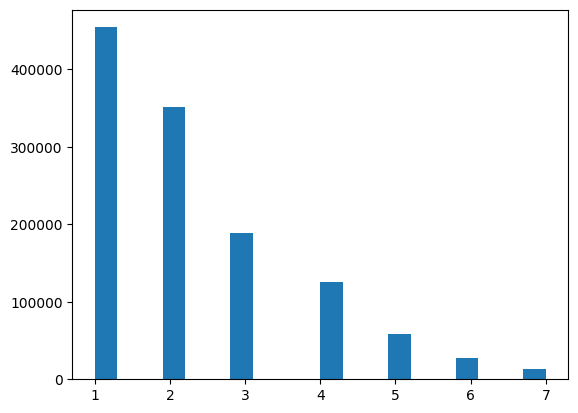

In [135]:
plt.hist(full_df[full_df["Nr_sentences"] < 8]["Nr_sentences"], bins=20)

In [136]:
full_df.groupby("Nr_sentences").count()

,Sentences,NACE_code,Cos_sim,Original_code,NACE_code_letter,Right_classification,Sentence_len
Nr_sentences,,,,,,,
1,454045,454045,454045,454045,454045,454045,454045
2,350685,350685,350685,350685,350685,350685,350685
3,188053,188053,188053,188053,188053,188053,188053
4,125792,125792,125792,125792,125792,125792,125792
5,58504,58504,58504,58504,58504,58504,58504
6,27486,27486,27486,27486,27486,27486,27486
7,12774,12774,12774,12774,12774,12774,12774
8,6181,6181,6181,6181,6181,6181,6181
9,2227,2227,2227,2227,2227,2227,2227


In [ ]:
full_df.groupby("Nr_sentences").agg({"Right_classification": np.mean})

/var/folders/fp/yhl61lbj3m73x3_17tsp1vrr0000gn/T/ipykernel_25769/465035233.py:1: FutureWarning: The provided callable <function mean at 0x103626170> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  full_df.groupby("Nr_sentences").agg({"Right_classification": np.mean})


,Right_classification
Nr_sentences,
1,0.123512
2,0.159308
3,0.178572
4,0.194257
5,0.198499
6,0.205086
7,0.205809
8,0.193982
9,0.189942


In [142]:
full_df.groupby("Nr_sentences").agg({"Sentence_len": np.mean})

/var/folders/fp/yhl61lbj3m73x3_17tsp1vrr0000gn/T/ipykernel_25769/2358799074.py:1: FutureWarning: The provided callable <function mean at 0x103626170> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  full_df.groupby("Nr_sentences").agg({"Sentence_len": np.mean})


,Sentence_len
Nr_sentences,
1,60.708348
2,156.842369
3,295.138620
4,417.183811
5,532.392640
6,630.392018
7,702.479333
8,754.844685
9,674.365514


In [138]:
full_df["Right_classification"].mean()

0.15622704857832337